# LAB1

## Imports

In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import copy
import pandas as pd

import os

In [2]:
# from google.colab import files
# uploaded = files.upload() # AI

## Data

### Load

In [3]:
# Load the data

data = scipy.io.loadmat("Xtrain.mat")
x = data["Xtrain"].astype(np.float32).flatten()

print(x.shape)
print(x[:10])
print("min:", x.min(), "max:", x.max(), "mean:", x.mean())

(1000,)
[ 86. 141.  95.  41.  22.  21.  32.  72. 138. 111.]
min: 2.0 max: 255.0 mean: 59.894


In [4]:
# data = scipy.io.loadmat("Xtrain.mat") # Load the data from the .mat file

# print(type(data))
# print(data.keys())

# x_raw = data["Xtrain"]

# print(type(x_raw))
# print(x_raw.shape)
# print(x_raw.dtype)
# print(x_raw[:10])

# #Flatten the data to a 1D array
# x = x_raw.astype(np.float32).flatten()

# print(x.shape)
# print(x[:20])

### Visualize

In [5]:
# Statistics of the data
print("Number of points:", len(x))
print("Minimum value:", x.min())
print("Maximum value:", x.max())
print("Mean value:", x.mean())
print("Standard deviation:", x.std())

Number of points: 1000
Minimum value: 2.0
Maximum value: 255.0
Mean value: 59.894
Standard deviation: 46.851986


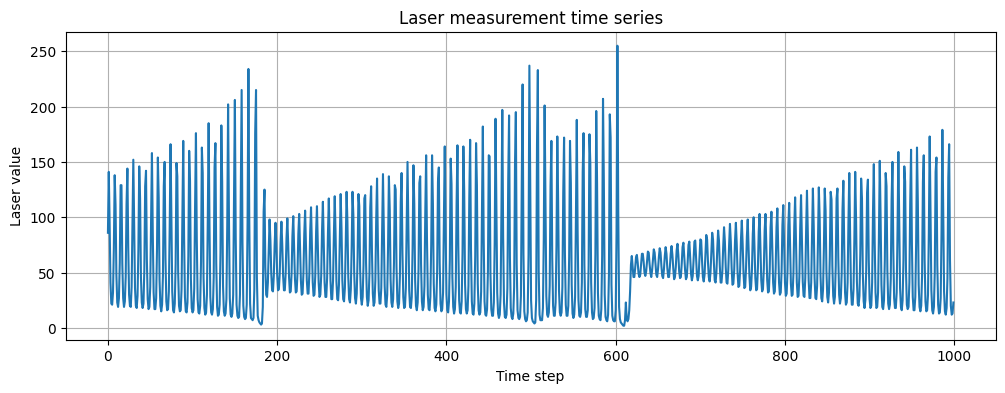

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(x)
plt.title("Laser measurement time series")
plt.xlabel("Time step")
plt.ylabel("Laser value")
plt.grid(True)
plt.show()

### Pre-processing

#### Splitting

In [7]:
train_pct = 0.8
train_end = int(train_pct*len(x))

train_data = x[:train_end]
val_data = x[train_end:]

#### Scaling

In [8]:
# Scale after splitting (based on training data max and min)
train_max = max(train_data)
train_min = min(train_data)

train_data_norm = (train_data - train_min) / (train_max - train_min)
val_data_norm = (val_data - train_min) / (train_max - train_min)


## Utils

### Data Processing Functions

In [9]:
# Windowing function

def create_windows(series, window_size):
    X = []
    y = []

    for i in range(len(series) - window_size):
        X.append(series[i:i + window_size])
        y.append(series[i + window_size])

    return np.array(X), np.array(y)

In [10]:
"""
    Input: np arrays
    Output: TorchDatasets
    Process np -> torch.tensor -> TensorDatasets
"""
def transform_to_tensor_dataset(
    x: np.ndarray,
    y: np.ndarray
) -> TensorDataset:
    x = torch.tensor(x, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)
    dataset = TensorDataset(x, y)

    return dataset

In [11]:
# De-scale data

def descale_data(x, xmax, xmin):
    return x*(xmax-xmin) + xmin

### Helpers

In [12]:
def determine_folder_path(model):
    if type(model) == MLP:
        return "ANN-MLP"

    if type(model) == TCN:
        return "TCN"
    

In [13]:
def mean_std_ignore_inf(values, fmt):
    values = np.asarray(values, dtype=float)
    finite_values = values[np.isfinite(values)]

    if len(finite_values) == 0:
        return "inf"

    return f"{np.mean(finite_values):{fmt}} += {np.std(finite_values):{fmt}}"

In [14]:
def save_results(stats):
    columns=["Best Epoch", "Patience", "1-step Val (x1e-05)", "Recursive Val (MSE)", "Recursive Val (MAE)"]
    stats_str = [[str(i).replace(".",",") for i in row] for row in stats]
    df_res = pd.DataFrame(stats_str, columns=columns)
    df_res.to_csv(model_name_path + r'/results.csv',index=False)

def save_to_all_results(stats):
    df_results_all = pd.read_csv(full_folder_path + r"/results_all.csv")

    global i_VARIATION

    new_row = {
        "variation":i_VARIATION,
        "dilations": dilations,
        "k": k,
        "kernel_size": basic_config["kernel_size"],
        "channels": channels,
        "dropout": dropout_VARIATION,
        "lr": lr,
        "batch_size": basic_config["batch_size"],
        "total_epochs": basic_config["epochs"],
        "patience": basic_config["patience"],
        "runs": basic_config["runs"],
        "best_epoch": f"{np.mean([i[0] for i in stats]):.2f} += {np.std([i[0] for i in stats]):.2f}",
        "val_loss_1_step": mean_std_ignore_inf([i[2] for i in stats], ".2e"),
        "MSE_rec": mean_std_ignore_inf([i[3] for i in stats], ".2f"),
        "MAE_rec": mean_std_ignore_inf([i[4] for i in stats], ".2f"),
    }
    df_results_all = pd.concat([df_results_all, pd.DataFrame([new_row])], ignore_index=True)

    df_results_all.to_csv(full_folder_path + r"/results_all.csv", index=False)

In [32]:

def ensure_best_results_csv(path, i):
    csv_path = os.path.join(path, f"best_results_variation_{i}.csv")

    if not os.path.exists(csv_path):
        df = pd.DataFrame([{
            "Best 1-step val": 10e05,
            "Best rec val (MSE)": 10e05,
            "Best rec val (MAE)": 10e05,
        }])

        df.to_csv(
            csv_path,
            index=False,
            decimal=","
        )

        print(f"Created: {csv_path}")
    else:
        print(f"Already exists: {csv_path}")

    return csv_path

### Recursive Generation Function

In [15]:
# Recursively generate samples

def recursive_data_generation(x, model, k, num_samples) -> np.ndarray:
    # Evaluation Mode
    model.eval()

    # Initialize predicted samples array
    predicted_samples = np.zeros(num_samples, dtype=np.float32)

    # Make sure x is torch.tensor and not np.ndarray
    if type(x) == np.ndarray:
        x = torch.tensor(x, dtype=torch.float32)

    # Make sure len(x) == k
    if len(x) > k:
        x = x[-k:].clone()
    elif len(x) < k:
        print(f"Window size of x must be at least {k} samples long")
        return np.empty((0, num_samples), dtype=np.float32)


    with torch.no_grad():
        for i in range(num_samples):
            # Predict next sample
            y = model(x.unsqueeze(0)) 
            y = y.squeeze()
            # Concatenate last-k window
            x = torch.cat([x[1:], y.view(1)])
            # Add to prediction samples array
            predicted_samples[i] = y.item()


    return predicted_samples


### Training functions

In [16]:
def compare_with_best_1_step_val(one_step_val_loss, model, full_folder_path):
    df_results = pd.read_csv(full_folder_path + r'/best_results.csv', decimal=",")
    current_best = df_results["Best 1-step val"].iloc[0] * 1e-05

    if one_step_val_loss < current_best:
        print(f"Best 1-step val loss so far, {one_step_val_loss:.4e}")
        df_results.loc[0, "Best 1-step val"] = one_step_val_loss / 1e-05

        df_results.to_csv(
            full_folder_path + r'/best_results.csv',
            index=False,
            decimal=","
        )

        best_model_path = full_folder_path + r"/model_best_1_step.pth"
        torch.save(model.state_dict(), best_model_path)

def compare_with_best_rec_val_mse(rec_val_loss, model, full_folder_path):
    df_results = pd.read_csv(full_folder_path + r'/best_results.csv', decimal=",")
    current_best = df_results["Best rec val (MSE)"].iloc[0]
    global best_variation_MSE

    if rec_val_loss < current_best:
        print(f"Best Rec MSE val loss so far, {rec_val_loss:.4f}")
        df_results.loc[0, "Best rec val (MSE)"] = rec_val_loss

        df_results.to_csv(
            full_folder_path + r'/best_results.csv',
            index=False,
            decimal=","
        )

        best_model_path = full_folder_path + r"/model_best_rec_val_mse.pth"
        torch.save(model.state_dict(), best_model_path)
    if rec_val_loss < best_variation_MSE:
        print(f"Best recursive MSE found for variation {i_VARIATION}\n\tscore: {rec_val_loss}\n\trun: {num_run}")
        best_model_path_variation = model_name_path + r"/model_best_rec_val_mse.pth"
        torch.save(model.state_dict(), best_model_path_variation)
        best_variation_MSE = rec_val_loss

def compare_with_best_rec_val_mae(rec_val_loss, model, full_folder_path):
    df_results = pd.read_csv(full_folder_path + r'/best_results.csv', decimal=",")
    current_best = df_results["Best rec val (MAE)"].iloc[0]
    global best_variation_MAE

    if rec_val_loss < current_best:
        print(f"Best Rec MAE val loss so far, {rec_val_loss:.4f}")
        df_results.loc[0, "Best rec val (MAE)"] = rec_val_loss

        df_results.to_csv(
            full_folder_path + r'/best_results.csv',
            index=False,
            decimal=","
        )

        best_model_path = full_folder_path + r"/model_best_rec_val_mae.pth"
        torch.save(model.state_dict(), best_model_path)
    # Compare with variation best
    if rec_val_loss < best_variation_MAE:
        print(f"Best recursive MAE found for variation {i_VARIATION}\n\tscore: {rec_val_loss}\n\trun: {num_run}")
        best_model_path_variation = model_name_path + r"/model_best_rec_val_mae.pth"
        torch.save(model.state_dict(), best_model_path_variation)
        best_variation_MAE = rec_val_loss

In [28]:
def train_model(model_type, best_variation_val_loss, initialize=None, verbose=False, verbose_freq=25):

    global k_VARIATION, dilations_VARIATION, channels_VARIATION, weight_decay_VARIATION, lr_VARIATION
    global epochs, kernel_size, train_loader, criterion
    global MLP, TCN, init_tcn_kaiming

    if model_type == "ANN-MLP":
        model = MLP(window_size=k_VARIATION)
    elif model_type == "TCN":
        model = TCN(dilations = dilations_VARIATION, hidden_channels = channels_VARIATION, kernel_size=kernel_size)
        if initialize == "He":
            model.apply(init_tcn_kaiming)
        
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr_VARIATION,
        weight_decay=weight_decay_VARIATION
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=lr_VARIATION)    
    train_losses = []
    val_losses = []
    iter_no_improvement = 0

    best_loss = np.inf
    best_epoch = -1
    best_model_state = None

    for epoch in range(epochs):

        # ---- TRAIN ----
        model.train()
        running_train_loss = 0.0
        

        # Fit on batch
        for x_batch, y_batch in train_loader:
            # Clear Gradients
            optimizer.zero_grad()

            # Forward Pass
            pred = model(x_batch).squeeze(-1)

            # Loss
            loss = criterion(pred, y_batch)

            # Backprop
            loss.backward()

            # Update weights
            optimizer.step()

            # Update Loss
            running_train_loss += loss.item()

        # Avg train loss across all batches of epoch
        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ---- VALIDATION ----
        model.eval()

        with torch.no_grad():
            val_pred = model(x_val_torch).squeeze()
            val_loss = criterion(val_pred, y_val_torch)
            val_losses.append(val_loss.item())

            if val_loss.item() < best_loss:
                best_loss = val_loss.item()
                best_epoch = epoch
                best_model_state = copy.deepcopy(model.state_dict())
                iter_no_improvement = 0 

            else:
                iter_no_improvement += 1
                if iter_no_improvement == early_stoppage_at:
                    print(f"Early stoppage at epoch {epoch} due to no improvement for {early_stoppage_at} epochs" )
                    break

        if verbose and epoch % verbose_freq == 0.0:
            print(f"Epoch {epoch+1}: Train={loss.item():.4e}, Val={val_loss.item():.4e}")


    print(f"Best validation loss: {best_loss}\nat epoch {best_epoch+1}")

    # Restore the weights to the best iteration
    model.load_state_dict(best_model_state)

    # Save the best model iteration
    if best_loss < best_variation_val_loss:
        print(f"New best model found for variation {i_VARIATION}, with val loss {best_loss:.2e}, during run {num_run}")
        model_full_path = model_name_path + r"/model_best_1_step_val_loss.pth"
        torch.save(model.state_dict(), model_full_path)
        best_variation_val_loss = best_loss

    compare_with_best_1_step_val(one_step_val_loss=best_loss, model=model, full_folder_path=full_folder_path)

    return model, best_variation_val_loss, train_losses, val_losses, best_epoch


In [18]:
def plot_loss(train_losses, val_losses):
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.legend()
    plt.title("Loss over epochs")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.show()

### Validation Functions

In [19]:
def predict_and_plot_val_data(model):
    val_prediction_norm = recursive_data_generation(x = train_data_norm[-k:], model = model,k=k,num_samples=len(val_data_norm))
    val_prediction_descaled = descale_data(x=val_prediction_norm, xmax=train_max, xmin=train_min)

    y_true = torch.tensor(val_data, dtype=torch.float32)
    y_pred = torch.tensor(val_prediction_descaled, dtype=torch.float32)

    crit_mse = nn.MSELoss()
    crit_mae = nn.L1Loss()

    loss_recursive_pred_MSE = crit_mse(y_true, y_pred).item()
    loss_recursive_pred_MAE = crit_mae(y_true, y_pred).item()

    print("Loss between validation data and recursive prediction:")
    print(f"\t- MSE: {loss_recursive_pred_MSE:.4f}")
    print(f"\t- MAE: {loss_recursive_pred_MAE:.4f}")

    compare_with_best_rec_val_mse(rec_val_loss=loss_recursive_pred_MSE, model=model, full_folder_path=full_folder_path)
    compare_with_best_rec_val_mae(rec_val_loss=loss_recursive_pred_MAE, model=model, full_folder_path=full_folder_path)

    val_true = np.asarray(val_data).flatten()
    val_pred = np.asarray(val_prediction_descaled).flatten()
    plot_recursive_forecast_results(val_pred, val_true)

    return loss_recursive_pred_MAE, loss_recursive_pred_MSE


def plot_recursive_forecast_results(val_pred, val_true):
    # Plot validation data vs prediction
    

    plt.figure(figsize=(10, 4))

    plt.plot(val_true, label="Validation data")
    plt.plot(val_pred, label="Recursive prediction")

    plt.xlabel("Prediction step")
    plt.ylabel("Value")
    plt.title("Recursive validation prediction vs ground truth")
    plt.legend()
    plt.grid(True)
    plt.show()


## ANN / MLP

### Variation 1

In [20]:
model_name = "Variation_1"

#### Windowing

In [67]:
k = 10
x_train, y_train = create_windows(series=train_data_norm, window_size=k)

x_val, y_val = create_windows(series=val_data_norm, window_size=k)

#### Torch Data Initialization

In [68]:
# Turn np -> TensorDataset

train_dataset = transform_to_tensor_dataset(x_train, y_train)
print("Number of training samples:", len(train_dataset))

x_val_torch = torch.tensor(x_val, dtype=torch.float32)
y_val_torch = torch.tensor(y_val, dtype=torch.float32)

Number of training samples: 790


#### Model 

In [69]:
class MLP(nn.Module):
    def __init__(self, window_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(window_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

In [70]:
model = MLP(window_size=k)
criterion = nn.MSELoss()
folder_name = determine_folder_path(model)
full_folder_path = os.path.join("results",folder_name, model_name)
os.makedirs(full_folder_path, exist_ok=True)

#### Training Config

##### Params

In [71]:
epochs = 1000
batch_size = 32
lr = 1e-03
early_stoppage_at = 100

##### Create DataLoader

In [72]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

# Check one batch
X_batch, y_batch = next(iter(train_loader))
print("One X batch:", X_batch.shape)
print("One y batch:", y_batch.shape)


One X batch: torch.Size([32, 10])
One y batch: torch.Size([32])


#### Train and Test (click run)

Epoch 1: Train=1.8362e-02, Val=1.4729e-02
Epoch 26: Train=3.0322e-04, Val=1.7391e-04
Epoch 51: Train=1.3096e-04, Val=5.1782e-05
Epoch 76: Train=1.7185e-04, Val=4.2134e-05
Epoch 101: Train=2.1691e-04, Val=5.5445e-05
Epoch 126: Train=3.3926e-04, Val=4.3338e-05
Epoch 151: Train=4.8234e-05, Val=5.9486e-05
Epoch 176: Train=2.8973e-05, Val=5.7000e-05
Epoch 201: Train=1.0346e-04, Val=3.4211e-05
Epoch 226: Train=7.4640e-05, Val=6.1957e-05
Epoch 251: Train=2.6394e-05, Val=3.1397e-05
Epoch 276: Train=4.3711e-05, Val=4.9864e-05
Epoch 301: Train=4.9957e-05, Val=3.0543e-05
Epoch 326: Train=3.5857e-05, Val=2.4061e-05
Epoch 351: Train=8.0299e-05, Val=5.0407e-05
Epoch 376: Train=5.3799e-05, Val=5.5247e-05
Epoch 401: Train=4.3298e-05, Val=2.3740e-05
Epoch 426: Train=1.1863e-04, Val=3.1219e-05
Epoch 451: Train=3.1382e-05, Val=2.7097e-05
Epoch 476: Train=1.1107e-04, Val=3.2997e-05
Epoch 501: Train=2.0604e-05, Val=2.6661e-05
Epoch 526: Train=6.3035e-05, Val=2.8738e-05
Epoch 551: Train=1.9579e-05, Val=2.49

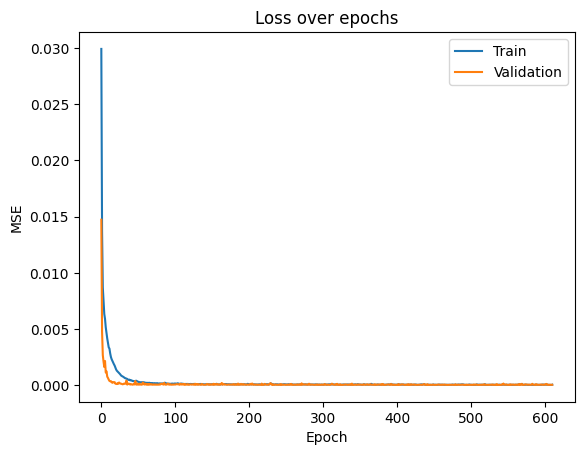

Loss between validation data and recursive prediction:
	- MSE: 2734.6592
	- MAE: 35.4136


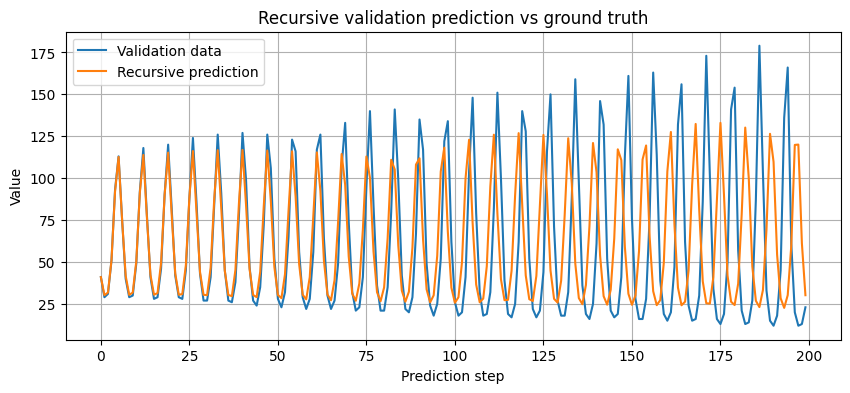

Epoch 1: Train=3.5527e-02, Val=1.5066e-02
Epoch 26: Train=3.3667e-04, Val=8.5178e-05
Epoch 51: Train=9.8281e-04, Val=5.8041e-05
Epoch 76: Train=1.3946e-04, Val=5.7570e-05
Epoch 101: Train=1.3137e-04, Val=7.3292e-05
Epoch 126: Train=1.3182e-04, Val=1.8071e-04
Epoch 151: Train=4.3526e-05, Val=3.7846e-05
Epoch 176: Train=1.3890e-04, Val=7.4246e-05
Epoch 201: Train=3.4666e-05, Val=5.3542e-05
Epoch 226: Train=2.5163e-05, Val=2.5779e-05
Epoch 251: Train=1.8586e-04, Val=5.7348e-05
Epoch 276: Train=3.2705e-05, Val=3.6355e-05
Epoch 301: Train=6.6037e-05, Val=3.2468e-05
Epoch 326: Train=3.6712e-05, Val=2.9071e-05
Epoch 351: Train=6.7719e-05, Val=6.9292e-05
Epoch 376: Train=3.9225e-05, Val=2.8357e-05
Epoch 401: Train=3.4782e-04, Val=8.1141e-05
Epoch 426: Train=1.2396e-05, Val=2.9299e-05
Epoch 451: Train=3.4388e-05, Val=4.0449e-05
Epoch 476: Train=1.0725e-04, Val=2.5800e-05
Early stoppage at epoch 498 due to no improvement for 100 epochs
Best validation loss: 2.1959393052384257e-05
at epoch 399


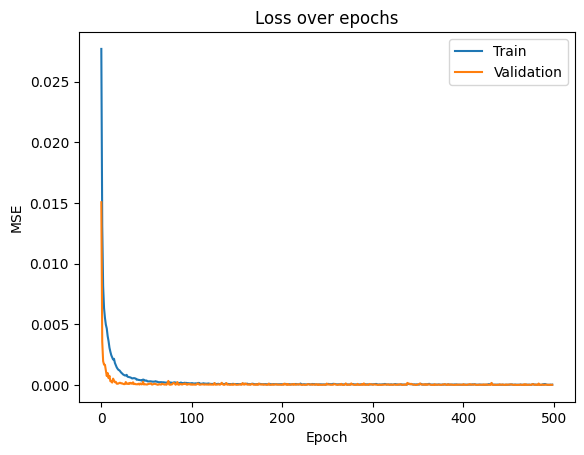

Loss between validation data and recursive prediction:
	- MSE: 2584.4136
	- MAE: 35.6177


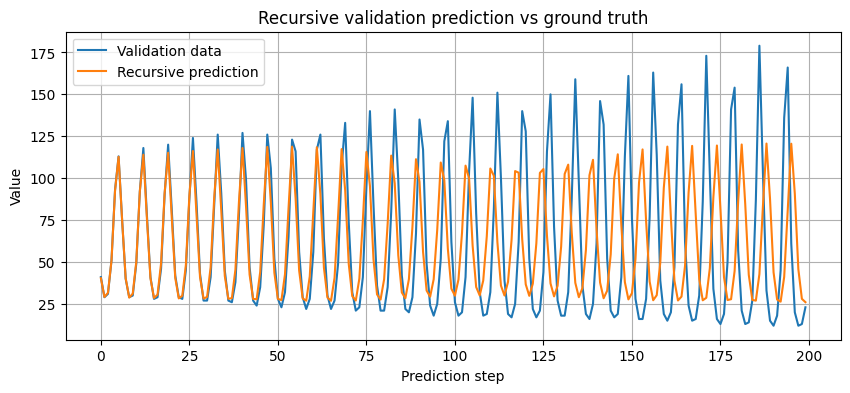

Epoch 1: Train=2.1174e-02, Val=1.2874e-02
Epoch 26: Train=1.0746e-03, Val=1.8548e-04
Epoch 51: Train=4.1970e-04, Val=5.2973e-05
Epoch 76: Train=1.1246e-03, Val=1.7499e-04
Epoch 101: Train=6.1920e-05, Val=6.5763e-05
Epoch 126: Train=3.6828e-05, Val=4.7538e-05
Epoch 151: Train=4.6890e-05, Val=8.4028e-05
Epoch 176: Train=1.3831e-04, Val=4.8609e-05
Epoch 201: Train=8.6272e-05, Val=5.2950e-05
Early stoppage at epoch 201 due to no improvement for 100 epochs
Best validation loss: 2.7849964681081474e-05
at epoch 102


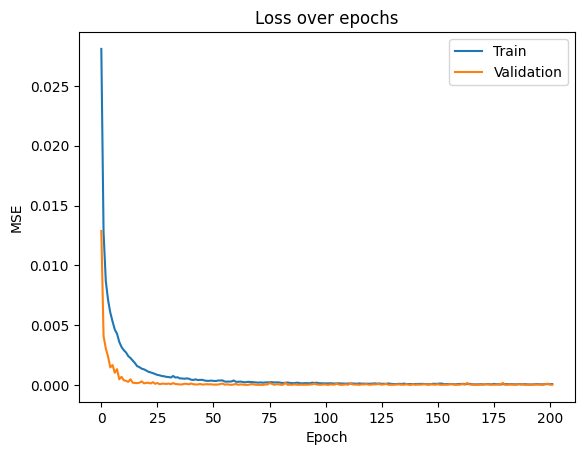

Loss between validation data and recursive prediction:
	- MSE: 97265968.0000
	- MAE: 961.2134


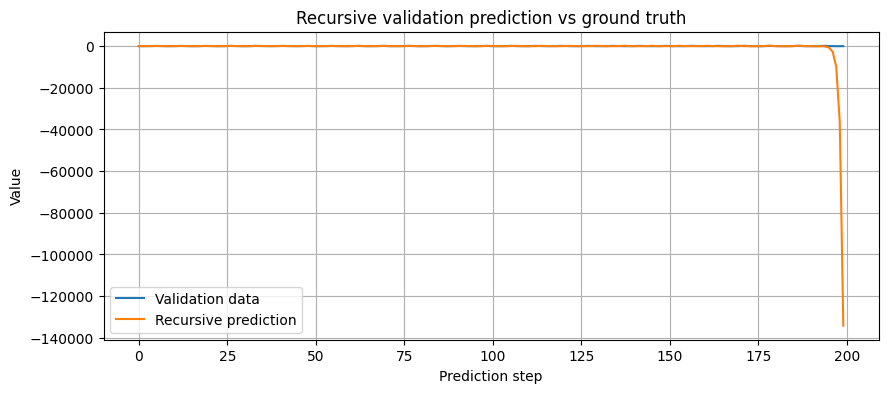

Epoch 1: Train=5.0814e-02, Val=4.0546e-02
Epoch 26: Train=4.1439e-04, Val=1.6779e-04
Epoch 51: Train=1.7156e-04, Val=2.6896e-04
Epoch 76: Train=1.7048e-04, Val=6.4724e-05
Epoch 101: Train=6.8415e-04, Val=7.1811e-05
Epoch 126: Train=8.3934e-05, Val=2.3294e-04
Epoch 151: Train=8.9359e-05, Val=1.7357e-04
Epoch 176: Train=6.4033e-05, Val=5.6677e-05
Early stoppage at epoch 186 due to no improvement for 100 epochs
Best validation loss: 4.281270594219677e-05
at epoch 87


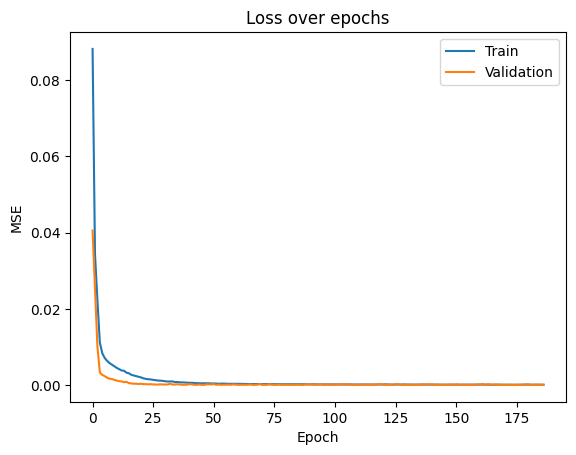

Loss between validation data and recursive prediction:
	- MSE: 4790.4604
	- MAE: 46.8353


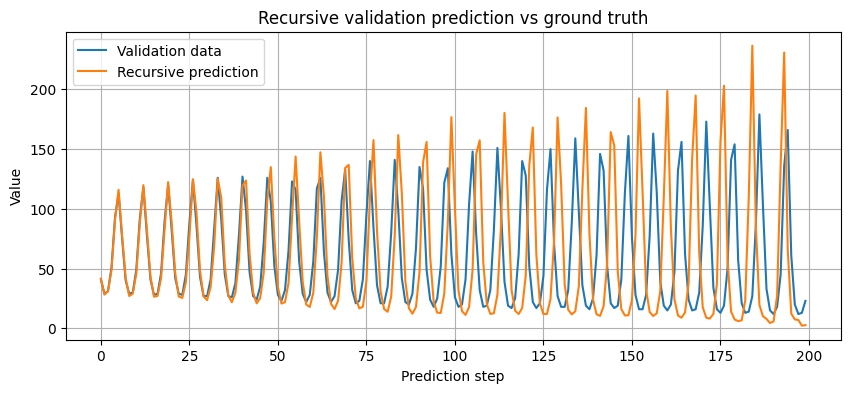

Epoch 1: Train=1.7421e-02, Val=3.5429e-02
Epoch 26: Train=3.4364e-04, Val=2.5346e-04
Epoch 51: Train=1.0839e-04, Val=1.2787e-04
Epoch 76: Train=2.2820e-03, Val=4.6424e-05
Epoch 101: Train=5.4920e-05, Val=5.4198e-05
Epoch 126: Train=5.4985e-05, Val=5.7999e-05
Epoch 151: Train=1.0317e-04, Val=1.2261e-04
Epoch 176: Train=5.4257e-05, Val=7.8153e-05
Epoch 201: Train=1.2807e-05, Val=7.4167e-05
Epoch 226: Train=1.2290e-04, Val=1.3467e-04
Epoch 251: Train=8.1267e-05, Val=5.1734e-05
Epoch 276: Train=2.5297e-05, Val=3.1691e-05
Early stoppage at epoch 293 due to no improvement for 100 epochs
Best validation loss: 2.8089050829294138e-05
at epoch 194


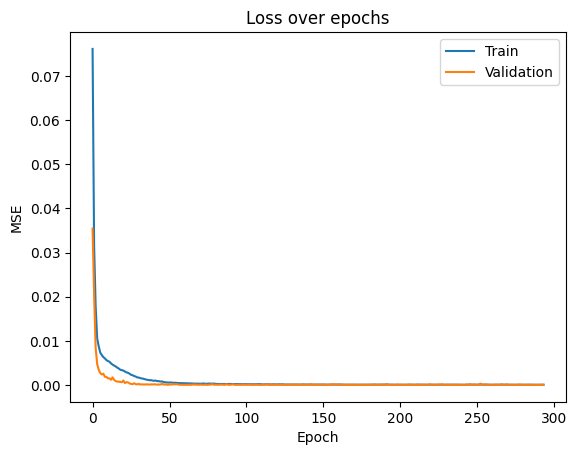

Loss between validation data and recursive prediction:
	- MSE: 52.2541
	- MAE: 4.0586


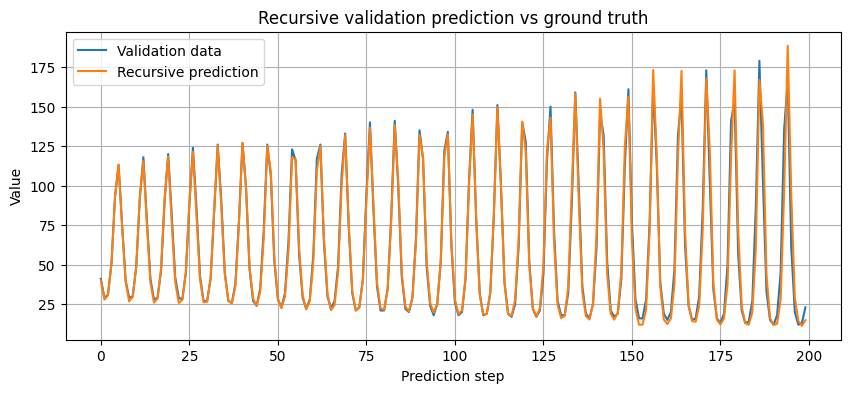

In [ ]:
stats = []

runs = 5

for i_VARIATION in range(runs):
    model, train_losses, val_losses, best_epoch = train_model(model_type =folder_name, verbose=True)
    plot_loss(train_losses, val_losses)

    mae, mse = predict_and_plot_val_data(model)
    stats.append([best_epoch, early_stoppage_at, f"{val_losses[best_epoch]/1e-05:.3f}", f"{mse:.2f}", f"{mae:.3f}"])

save_results(stats=stats)

In [93]:
save_results(stats=stats)

,Best Epoch,Patience,1-step Val (x1e-05),Recursive Val (MSE),Recursive Val (MAE)
0,56,100,2.850,67.55,5.401
1,587,100,2.126,429.74,12.839
2,254,100,2.644,5094.19,49.307
3,822,100,1.846,2625.34,33.109
4,127,100,2.905,2093.22,32.963


#### Recursive Test Sample Generation

In [ ]:
test_sample_prediction_norm = recursive_data_generation(
    x=val_data_norm[-k:], 
    model=model, 
    k=k, 
    num_samples=200
)

test_sample_descaled = descale_data(test_sample_prediction_norm, train_max, train_min)


## TCN

### TCN Utils

In [20]:
def init_tcn_kaiming(m):
    if isinstance(m, nn.Conv1d):
        nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
        if m.bias is not None:
            nn.init.zeros_(m.bias)

    elif isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight, gain=0.1)
        if m.bias is not None:
            nn.init.zeros_(m.bias)


### Variations

#### Windowing

In [ ]:
# k = 20
# x_train, y_train = create_windows(series=train_data_norm, window_size=k)
# x_val, y_val = create_windows(series=val_data_norm, window_size=k)

#### Torch Data Initialization

In [20]:
# Turn np -> TensorDataset

train_dataset = transform_to_tensor_dataset(x_train, y_train)
print("Number of training samples:", len(train_dataset))

x_val_torch = torch.tensor(x_val, dtype=torch.float32)
y_val_torch = torch.tensor(y_val, dtype=torch.float32)

NameError: name 'x_train' is not defined

#### Model 


In [21]:
class TCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.0):
        super().__init__()

        # Padding to ensure causality
        #   out[k]  must only take into account samples input[i] for i < k
        #   dilation = spacing out the kernel using '0's in between its values
        padding = (kernel_size - 1) * dilation

        self.conv = nn.Conv1d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            padding=padding,
            dilation=dilation
        )

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        # Residual block: either keeps the sequences as they are (convolves with Identity Matrix) or convolves with #out_channels 1x1 kernels in case number of channels changes
        self.residual = nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        y = self.conv(x)

        # crop extra padded values to preserve initial length -> cancel out effect of padding on the right side
        # Shape: batch, channels, time
        y = y[:, :, :x.shape[2]]

        res = self.residual(x)

        # Output = result of convolution + output of residual block
        return self.relu(y + res)


class TCN(nn.Module):
    def __init__(self, dilations, hidden_channels, kernel_size, dropout=0.0):
        super().__init__()

        self.tcn_blocks = nn.ModuleList([
            TCNBlock(
                in_channels=hidden_channels if i > 0 else 1,
                out_channels=hidden_channels,
                kernel_size=kernel_size,
                dilation=d,
                dropout=dropout
            )
            for i, d in enumerate(dilations)
        ])

        self.fc = nn.Linear(hidden_channels, 1)

    def forward(self, x):
        # x: [batch, sequence_length]
        x = x.unsqueeze(1)
        # x: [batch, 1, sequence_length]

        for block in self.tcn_blocks:
            x = block(x)

        # x: [batch, hidden_channels, sequence_length]
        last_step = x[:, :, -1]
        # last_step: [batch, hidden_channels]

        return self.fc(last_step)



In [22]:
# model = TCN()
# criterion = nn.MSELoss()

# # Initialization
# # model.apply(init_tcn_kaiming)

# folder_name = determine_folder_path(model)
# full_folder_path = os.path.join("results",folder_name, model_name)
# os.makedirs(full_folder_path, exist_ok=True)

#### Training Config

##### Params

In [23]:
basic_config = {
    "epochs": 1500,
    "patience": 200,
    "batch_size": 32,
    "kernel_size": 3,
    "runs" : 5
}

# folder_name = determine_folder_path(model)
# full_folder_path = os.path.join("results",folder_name, model_name)
# os.makedirs(full_folder_path, exist_ok=True)

tcn_test_grid = [
    # --------------------
    # k = 10
    # --------------------
    {"k": 10, "dilations": [1, 2],       "channels": 8,  "lr": 1e-3},
    {"k": 10, "dilations": [1, 2, 4],    "channels": 16, "lr": 1e-3},
    {"k": 10, "dilations": [1, 2, 4],    "channels": 16, "lr": 5e-4},
    {"k": 10, "dilations": [1, 2, 4],    "channels": 32, "lr": 5e-4},

    # --------------------
    # k = 20
    # --------------------
    {"k": 20, "dilations": [1, 2, 4],       "channels": 8,  "lr": 1e-3},
    {"k": 20, "dilations": [1, 2, 4, 8],    "channels": 16, "lr": 1e-3},
    {"k": 20, "dilations": [1, 2, 4, 8],    "channels": 16, "lr": 5e-4},
    {"k": 20, "dilations": [1, 2, 4, 8],    "channels": 32, "lr": 5e-4},

    # --------------------
    # k = 50
    # --------------------
    {"k": 50, "dilations": [1, 2, 4, 8],        "channels": 8,  "lr": 1e-3},
    {"k": 50, "dilations": [1, 2, 4, 8, 16],    "channels": 16, "lr": 1e-3},
    {"k": 50, "dilations": [1, 2, 4, 8, 16],    "channels": 16, "lr": 5e-4},
    {"k": 50, "dilations": [1, 2, 4, 8, 16],    "channels": 32, "lr": 5e-4},
    {"k": 50, "dilations": [1, 2, 4, 8, 16],    "channels": 16, "lr": 1e-4},

    # --------------------
    # k = 100
    # --------------------
    {"k": 100, "dilations": [1, 2, 4, 8, 16],       "channels": 8,  "lr": 1e-3},
    {"k": 100, "dilations": [1, 2, 4, 8, 16, 32],   "channels": 16, "lr": 1e-3},
    {"k": 100, "dilations": [1, 2, 4, 8, 16, 32],   "channels": 16, "lr": 5e-4},
    {"k": 100, "dilations": [1, 2, 4, 8, 16, 32],   "channels": 32, "lr": 5e-4},
    {"k": 100, "dilations": [1, 2, 4, 8, 16, 32],   "channels": 16, "lr": 1e-4},

    # --------------------
    # Extra stability checks
    # --------------------
    {"k": 20, "dilations": [1, 2, 4, 4],       "channels": 16, "lr": 5e-4},
    {"k": 50, "dilations": [1, 2, 4, 8, 8],    "channels": 16, "lr": 5e-4},
    # Best current candidate: k=100, channels=8, lr=1e-3
    {"k": 100, "dilations": [1, 2, 4, 8, 16],     "channels": 8,  "lr": 1e-3, "dropout": 0.0},
    {"k": 100, "dilations": [1, 2, 4, 8, 16],     "channels": 8,  "lr": 1e-3, "dropout": 0.05},
    {"k": 100, "dilations": [1, 2, 4, 8, 16],     "channels": 8,  "lr": 1e-3, "dropout": 0.1},

    # Same structure, more channels
    {"k": 100, "dilations": [1, 2, 4, 8, 16],     "channels": 16, "lr": 1e-3, "dropout": 0.0},
    {"k": 100, "dilations": [1, 2, 4, 8, 16],     "channels": 16, "lr": 1e-3, "dropout": 0.05},
    {"k": 100, "dilations": [1, 2, 4, 8, 16],     "channels": 16, "lr": 1e-3, "dropout": 0.1},

    # Longer dilation , smaller channels
    {"k": 100, "dilations": [1, 2, 4, 8, 16, 32], "channels": 8,  "lr": 1e-3, "dropout": 0.0},
    {"k": 100, "dilations": [1, 2, 4, 8, 16, 32], "channels": 8,  "lr": 1e-3, "dropout": 0.05},
    {"k": 100, "dilations": [1, 2, 4, 8, 16, 32], "channels": 8,  "lr": 1e-3, "dropout": 0.1},

    # Good k=20 candidate
    {"k": 20,  "dilations": [1, 2, 4, 8],         "channels": 16, "lr": 5e-4, "dropout": 0.0},
    {"k": 20,  "dilations": [1, 2, 4, 8],         "channels": 16, "lr": 5e-4, "dropout": 0.05},
    {"k": 20,  "dilations": [1, 2, 4, 8],         "channels": 16, "lr": 5e-4, "dropout": 0.1},

    # Good k=50 candidate
    {"k": 50,  "dilations": [1, 2, 4, 8, 16],     "channels": 32, "lr": 5e-4, "dropout": 0.0},
    {"k": 50,  "dilations": [1, 2, 4, 8, 16],     "channels": 32, "lr": 5e-4, "dropout": 0.05},
    {"k": 50,  "dilations": [1, 2, 4, 8, 16],     "channels": 32, "lr": 5e-4, "dropout": 0.1},

    # More Aggressive Dropout
    {"k": 100, "dilations": [1, 2, 4, 8, 16],     "channels": 16, "lr": 1e-3, "dropout": 0.2},
    {"k": 50,  "dilations": [1, 2, 4, 8, 16],     "channels": 32, "lr": 5e-4, "dropout": 0.2},
]

In [24]:
# epochs = 1000
# batch_size = 32
# lr = 1e-03
# early_stoppage_at = 100

##### Create DataLoader

In [ ]:
# train_loader = DataLoader(
#     train_dataset,
#     batch_size=batch_size,
#     shuffle=True
# )

# Check one batch
# X_batch, y_batch = next(iter(train_loader))
# print("One X batch:", X_batch.shape)
# print("One y batch:", y_batch.shape)


One X batch: torch.Size([32, 20])
One y batch: torch.Size([32])


#### Train and Test (click run)

In [33]:

epochs = basic_config["epochs"]
early_stoppage_at = basic_config["patience"]
batch_size = basic_config["batch_size"]
kernel_size = basic_config["kernel_size"]
runs = basic_config["runs"]

folder_name = "TCN"

criterion = nn.MSELoss()

# Best scores
best_variation_val_loss = np.inf
best_variation_MSE = np.inf
best_variation_MAE = np.inf

for i_VARIATION, config_VARIATION in enumerate(tcn_test_grid,start=1):
    stats = []
    model_name = f"Variation_{i_VARIATION}"
    print(model_name)

    for key,val in config_VARIATION.items():
        print(f"'{key} : {val}'")

    full_folder_path = os.path.join("results",folder_name)
    model_name_path = os.path.join(full_folder_path, model_name)
    os.makedirs(model_name_path, exist_ok=True)
    ensure_best_results_csv(path = model_name_path, i=i_VARIATION)


    # Best scores
    best_variation_val_loss = np.inf
    best_variation_MSE = np.inf
    best_variation_MAE = np.inf


    k_VARIATION = config_VARIATION["k"]
    dilations_VARIATION = config_VARIATION["dilations"]
    channels_VARIATION = config_VARIATION["channels"]
    lr_VARIATION = config_VARIATION["lr"]

    try:   
        dropout_VARIATION = config_VARIATION["dropout"]
    except KeyError:
        dropout_VARIATION = 0.0

    try:   
        weight_decay_VARIATION = config_VARIATION["weight_decay"]
    except KeyError:
        weight_decay_VARIATION = 0.0


    # Create DataLoaders
    x_train, y_train = create_windows(series=train_data_norm, window_size=k_VARIATION)
    x_val, y_val = create_windows(series=val_data_norm, window_size=k_VARIATION) 
    train_dataset = transform_to_tensor_dataset(x_train, y_train)

    x_val_torch = torch.tensor(x_val, dtype=torch.float32)
    y_val_torch = torch.tensor(y_val, dtype=torch.float32)
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )


    for num_run in range(1, runs+1):
        print(f"Variation: {i_VARIATION}, run {num_run}")
        print(f"\tBest val loss: {best_variation_val_loss}")
        print(f"\tBest Recursive MSE: {best_variation_MSE}")
        print(f"\tBest Recursive MAE: {best_variation_MAE}")
        model, best_variation_val_loss, train_losses, val_losses, best_epoch = train_model(model_type = folder_name, best_variation_val_loss=best_variation_val_loss, verbose=True, verbose_freq=200)
        # plot_loss(train_losses, val_losses)

        mae, mse = predict_and_plot_val_data(model)
        stats.append([best_epoch, early_stoppage_at, f"{val_losses[best_epoch]/1e-05:.3f}", f"{mse:.2f}", f"{mae:.3f}"])

    save_results(stats=stats)
    save_to_all_results(stats=stats)

Variation_1
'k : 10'
'dilations : [1, 2]'
'channels : 8'
'lr : 0.001'
Created: results\TCN\Variation_1\best_results_variation_1.csv
Variation: 1, run 1
	Best val loss: inf
	Best Recursive MSE: inf
	Best Recursive MAE: inf
Epoch 1: Train=8.5458e-03, Val=8.7085e-03


KeyboardInterrupt: 

In [ ]:
# df_results_all = pd.read_csv(full_folder_path + r"/results_all.csv")
# insert_pos = df_results_all.columns.get_loc("dropout") + 1

# df_results_all.insert(insert_pos, "weight_decay", 0.0)
# df_results_all.to_csv(full_folder_path + r"/results_all.csv", index=False)


In [37]:
df = pd.read_csv(model_name_path + r"/best_results_variation_1.csv")
float(df["Best 1-step val"])

C:\Users\tasos\AppData\Local\Temp\ipykernel_12992\2246560383.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(df["Best 1-step val"])


ValueError: could not convert string to float: '1000000,0'

#### Recursive Test Sample Generation

In [ ]:
test_sample_prediction_norm = recursive_data_generation(
    x=val_data_norm[-k:], 
    model=model, 
    k=k, 
    num_samples=200
)

test_sample_descaled = descale_data(test_sample_prediction_norm, train_max, train_min)